In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pieridae.starbursts.byol import BYOLModelManager, FrozenClassifier, compute_classification_metrics


import sys
sys.path.append('../scripts/')
import run_analysis

/Users/kadofong/opt/miniconda3/envs/merian/lib/python3.10/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(


In [3]:
config = run_analysis.load_config('../configs/galaxyzoo.yaml')
output_path = run_analysis.Path('../output/galaxy_zoo/')
logger = run_analysis.setup_logging(output_path)

In [41]:
label_file = '/Users/kadofong/work/projects/merian/quick_projects/vizinspect/scripts/classifications_msorabove_v0_test.csv'
label_file = '/Users/kadofong/work/projects/merian/pieridae/merger_analysis/local_data/galaxy_zoo_classifications/classifications_test.csv'
test = pd.read_csv(label_file, index_col=0)
test = test.query('classification>0')
#test = test.iloc[-3000:]

In [42]:
images, img_names = run_analysis.load_merian_images(
    config['data']['input_path'],
    logger,
    names = test.index
)

2025-12-29 12:05:21,363 - byol_analysis - INFO - Found 70 target files out of 3565 requested.
2025-12-29 12:05:21,364 - byol_analysis - INFO - Found 70 image files
2025-12-29 12:05:21,364 - byol_analysis - INFO - Counting valid images...
Validating files: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:00<00:00, 31364.31it/s]
2025-12-29 12:05:21,368 - byol_analysis - INFO - Found 70 valid image sets
Loading images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:00<00:00, 501.39it/s]
2025-12-29 12:05:21,511 - byol_analysis - INFO - Loaded 70 images with shape: (70, 3, 150, 150)


In [43]:
model_manager = BYOLModelManager(config, output_path, logger)

2025-12-29 12:05:21,553 - byol_analysis - INFO - Using Apple Silicon GPU (MPS): mps
2025-12-29 12:05:21,554 - byol_analysis - INFO - BYOLModelManager initialized on device: mps


In [44]:
classifier = FrozenClassifier(
    model_path=output_path / 'best_model_checkpoint.pt',
    config=config,
    logger=logger,
    n_classes=5     
)

2025-12-29 12:05:21,592 - byol_analysis - INFO - FrozenClassifier using device: mps
2025-12-29 12:05:21,592 - byol_analysis - INFO - Loading trained classifier from: ../output/galaxy_zoo/best_model_checkpoint.pt
2025-12-29 12:05:22,586 - byol_analysis - INFO - Loaded classifier: 512 -> 5 classes


In [45]:
logger.info("Running classification...")
embeddings = model_manager.extract_embeddings(images, save=False)
iterative_labels, n_labels_iter, prob_labels_iter, stats = \
    classifier.iterative_propagation(embeddings, test, )
predicted_labels = np.argmax(prob_labels_iter, axis=1)

2025-12-29 12:05:22,632 - byol_analysis - INFO - Running classification...
2025-12-29 12:05:22,632 - byol_analysis - INFO - Extracting embeddings from 70 images...
2025-12-29 12:05:22,633 - byol_analysis - INFO - Loading trained model from: ../output/galaxy_zoo/byol_final_model.pt
2025-12-29 12:05:22,633 - byol_analysis - INFO - Setting up BYOL model...
2025-12-29 12:05:23,070 - byol_analysis - INFO - Created classification head: 512 -> 5 classes
2025-12-29 12:05:23,071 - byol_analysis - INFO - BYOL model setup complete on mps
2025-12-29 12:05:23,188 - byol_analysis - INFO - Loaded classifier from checkpoint
2025-12-29 12:05:23,189 - byol_analysis - INFO - Model loaded successfully
Extracting embeddings: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 22.45it/s]
2025-12-29 12:05:23,281 - byol_analysis - INFO - Extracted embeddings shape: (70, 512)
2025-12-29 12:05:23,283 - byol_

In [46]:
if 'galaxy_zoo' in label_file:
    class_names = {1:'notEoD', 2:'EoD', 3:'EoD'}
    def combine_mergers(x):
        return x

else:
    class_names = {1:'UD',2:'AMB',3:'TF',4:'FRAG',5:'ART'}

    def combine_mergers(x):
        return np.where(x==2, 3, x)

metrics = compute_classification_metrics(
    combine_mergers(test.reindex(img_names)['classification'].values),
    combine_mergers(predicted_labels),
    dict([ x for x in class_names.items() if x[0] in 
          np.unique(combine_mergers(np.concatenate([predicted_labels, test['classification'].values]))) ])
)

[1, 2]
[1 2 1 2 2 1 1 1 2 2 1 1 1 2 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 2 2
 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1 1 1 2 1 1 2 1 2 1 1 1 1 1 1 2 1 1 1]
[1 2 1 1 1 1 1 1 2 1 2 1 1 2 1 1 1 1 1 1 1 2 1 2 2 1 1 1 1 1 1 1 1 1 1 2 2
 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 1 1 2 1 1 2 1 2 2 1 1 1 1 1 1 1 1 1]


Text(0.5, 1.0, 'Confusion Matrix')

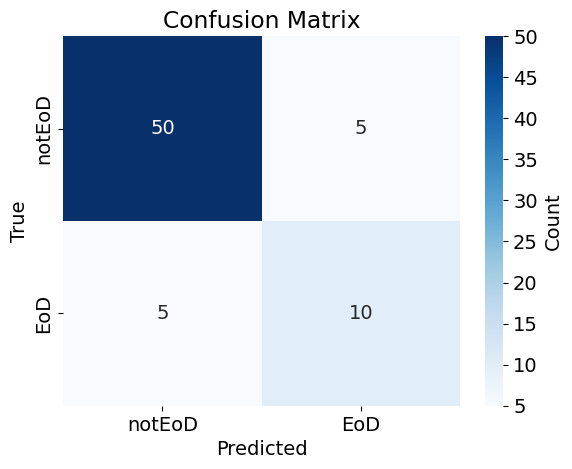

In [47]:
ax = plt.subplot(111)
conf_matrix = np.array(metrics['confusion_matrix'])
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(metrics['class_names'].values()),
    yticklabels=list(metrics['class_names'].values()),
    ax=ax,
    cbar_kws={'label': 'Count'}
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
#plt.savefig('/Users/kadofong/Desktop/test.png')

In [48]:
from ekfplot import plot as ek
from matplotlib import colors
import cmasher

In [49]:
human_labels = test.reindex(img_names)['classification'].values
if 'galaxy_zoo' in label_file:
    tags = {1:'not EO disk', 2:'Edge-on disk'}
else:
    tags = {1:'undisturbed',2:'ambiguous',3:'merger', 4:'fragmented', 5:'artifact'}
pred_ud_actual_tf= (predicted_labels==1)&(np.in1d(human_labels,[2,3]))
pred_tf_actual_ud = np.in1d(predicted_labels,[2,3])&(np.in1d(human_labels,[1,4]))

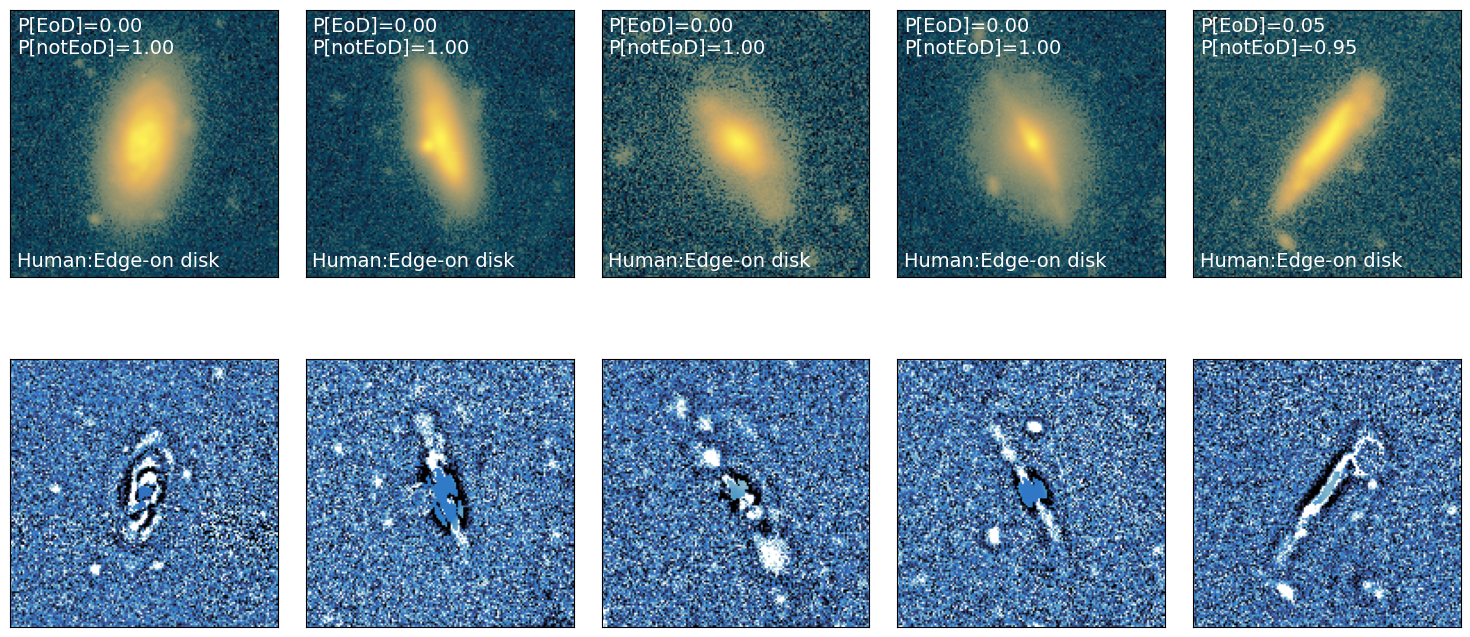

In [56]:
mask = pred_ud_actual_tf
samp = images[mask]
ptf = prob_labels_iter[mask][:,[2,3]].sum(axis=1)
pud = prob_labels_iter[mask,1]
fig, axarr = plt.subplots(2, len(samp), figsize=(len(samp)*3, 8))
for idx,img in enumerate(samp):

    axarr[0, idx].imshow(img[0], origin='lower', cmap=cmasher.eclipse, norm=colors.SymLogNorm(1e-1))
    ek.text(
        0.025,
        0.975,
        f'P[{class_names[3]}]={ptf[idx]:.2f}\nP[{class_names[1]}]={pud[idx]:.2f}',
        ax=axarr[0,idx],
        color='w'
    )
    ek.text(
        0.025,
        0.025,
        f'Human:{tags[human_labels[mask][idx]]}',
        ax=axarr[0,idx],
        color='w'
    )
    ek.imshow(img[2], ax=axarr[1, idx], cmap=cmasher.arctic)

for ax in axarr.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.tight_layout()
plt.savefig('/Users/kadofong/Desktop/misclass.png')

In [231]:
prob_labels_iter[0]

array([0.00000000e+00, 9.99999881e-01, 1.06245793e-07, 1.94550047e-08,
       6.09376301e-08, 2.56591481e-09])